# Assignment: Marketing Campaign Data Analysis and Modeling

**Welcome, aspiring Enggineers !** In this assignment, you will work with a real-world marketing campaign dataset. Your goal is to clean, transform, explore, and engineer new features to prepare the data for analysis and, eventually, for machine learning models.

Follow the steps in this guide to make the data ready for insightful analysis.

---

### Initial Setup
First, let's import the necessary libraries for our analysis.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set plotting style
sns.set(style='whitegrid')

---

## 📚 Part 1: Data Cleaning & Exploratory Data Analysis (EDA)

**Goal:** To understand the raw dataset, identify any initial problems, and perform basic cleaning.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salmaemadali/marketing-campaign")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/marketing-campaign


### 1. Load and Explore the Data

**Task:** Load the `marketing_campaign.csv` file into a Pandas DataFrame. Remember that the separator in this file is a tab (`\t`).

In [3]:

file_name = '/kaggle/input/marketing-campaign/marketing_campaign.csv'
df = pd.read_csv(file_name, sep='\t')



**Task:** Use the `.head()`, `.info()`, `.describe()`, and `.shape` functions to get a first look at your data.

In [4]:
# Get the first 5 rows
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
# Get a summary of the DataFrame
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [6]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [7]:
# Get statistical summary for numerical columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
# Get the dimensions of the DataFrame (rows, columns)
df.shape

(2240, 29)

**Question:** Based on these initial outputs, what are your first observations about the data types, number of entries, and potential missing values?


1-education ,Marital_Status (obbject)  to numerical use Encoding

2- Dt_customer  convert to (datetime)

3- Income 24 null  use (median)

4- Z_CostContact , Z_Revenue (drop constant ) std =0

5-Income have max $666,666.00 outlier

### 2. Data Cleansing

You will notice two columns, `Z_CostContact` and `Z_Revenue`, that have the same value for every single row.

**Explain:** Why are columns with a single, constant value not useful for building machine learning models?

**Answer Here:**
not effective for :

1- not have varience so the model cant learn relation between feauture and target

2- not effecte in change when have yes or no



**Task:** Remove these two columns from your DataFrame.

In [9]:
# TASK: Drop the unnecessary columns
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'])

---

## 📝 Part 2: Handling Missing Data

**Goal:** To properly address empty (`NaN`) values to ensure data quality.

### 1. Identify Missing Values

**Task:** Use the `.isna().sum()` function to identify which columns contain missing values and how many.

In [10]:
# TASK: Find the sum of missing values for each column
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
dtype: int64

### 2. Imputation Strategy

**Task:** Fill the missing values in the `Income` column using the column's **mean**.

In [11]:
# TASK: Fill missing income values with the mean
df['Income'].fillna(df['Income'].median(), inplace=True)

# Verify that there are no more missing values
df.isna().sum()

/tmp/ipykernel_13/2867116698.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
dtype: int64

**Question:** Why might using the mean be a suitable choice here? In what situations might using the **median** be a better choice?

**Your Answer Here:**

in marketing data use median imputation strategy because have outlier in data

---

## 🛠️ Part 3: Feature Engineering & Transformation

**Goal:** To create new, more meaningful features from existing ones to improve model performance.

### 1. Create New Features

**Task:** Create the new features as described below.
- Create New Features: Create the following new columns in your DataFrame:

- Age: Calculate the customer's age from the Year_Birth column. (You can use 2025 as the current year for calculation).

- Kids: Create a feature for the total number of children in the household by summing Kidhome and Teenhome.

- Expenses: Create a column representing the total amount spent by summing all columns that start with Mnt... (e.g., MntWines, MntFruits, etc.).

- TotalAcceptedCmp: Create a column that counts the total number of campaigns a customer responded to. Sum the columns from AcceptedCmp1 to AcceptedCmp5 and the Response column.

- NumTotalPurchases: Create a column for the total number of purchases made. Sum the NumWebPurchases, NumCatalogPurchases, NumStorePurchases, and NumDealsPurchases columns.

- day_engaged: Create a feature that shows how many days a customer has been with the company. (Hint: You will need to convert the Dt_Customer column to a datetime format and then calculate the difference between that date and a recent date, like '2025-01-01').



In [12]:
# TASK: Create 'Age' column. We'll use 2025 as the reference year for consistency.
reference_year = 2025
df['Age'] = reference_year - df['Year_Birth']

print(df[['Year_Birth', 'Age']].head())

   Year_Birth  Age
0        1957   68
1        1954   71
2        1965   60
3        1984   41
4        1981   44


In [13]:


# TASK: Create 'Kids' column by summing 'Kidhome' and 'Teenhome' columns
df['Kids'] = df['Kidhome'] + df['Teenhome']

print("'Kids' column created successfully.")


print("\nVerifying values:")
print(df[['Kidhome', 'Teenhome', 'Kids']].head())

'Kids' column created successfully.

Verifying values:
   Kidhome  Teenhome  Kids
0        0         0     0
1        1         1     2
2        0         0     0
3        1         0     1
4        1         0     1


In [14]:
# TASK: Create 'Expenses' column
# df['Expenses'] = ...
# TASK: Create 'Expenses' column by summing all columns that start with 'Mnt'

# 1. Identify all columns that start with 'Mnt'
mnt_cols = [col for col in df.columns if col.startswith('Mnt')]

# 2. Sum the values of these columns row-wise (axis=1) and assign the result to 'Expenses'
df['Expenses'] = df[mnt_cols].sum(axis=1)

print("'Expenses' column created successfully.")


print("\nVerifying values (MntWines + MntFruits + ... = Expenses):")
print(df[mnt_cols + ['Expenses']].head())

'Expenses' column created successfully.

Verifying values (MntWines + MntFruits + ... = Expenses):
   MntWines  MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  \
0       635         88              546              172                88   
1        11          1                6                2                 1   
2       426         49              127              111                21   
3        11          4               20               10                 3   
4       173         43              118               46                27   

   MntGoldProds  Expenses  
0            88      1617  
1             6        27  
2            42       776  
3             5        53  
4            15       422  


In [15]:

# TASK: Create TotalAcceptedCmp column

# Define the list of campaign columns
cmp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']

# Sum the values of these columns row-wise (axis=1) and assign the result to 'TotalAcceptedCmp'
df['TotalAcceptedCmp'] = df[cmp_cols].sum(axis=1)

print("'TotalAcceptedCmp' column created successfully.")

print(df[cmp_cols + ['TotalAcceptedCmp']].head())

'TotalAcceptedCmp' column created successfully.
   AcceptedCmp1  AcceptedCmp2  AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  \
0             0             0             0             0             0   
1             0             0             0             0             0   
2             0             0             0             0             0   
3             0             0             0             0             0   
4             0             0             0             0             0   

   Response  TotalAcceptedCmp  
0         1                 1  
1         0                 0  
2         0                 0  
3         0                 0  
4         0                 0  


In [16]:

# TASK: Create NumTotalPurchases column

# 1. Define the list of purchase columns to be summed
purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases']

# 2. Sum the values of these columns row-wise (axis=1) and assign the result to 'NumTotalPurchases'
df['NumTotalPurchases'] = df[purchase_cols].sum(axis=1)

print("'NumTotalPurchases' column created successfully.")


print(df[purchase_cols + ['NumTotalPurchases']].head())

'NumTotalPurchases' column created successfully.
   NumWebPurchases  NumCatalogPurchases  NumStorePurchases  NumDealsPurchases  \
0                8                   10                  4                  3   
1                1                    1                  2                  2   
2                8                    2                 10                  1   
3                2                    0                  4                  2   
4                5                    3                  6                  5   

   NumTotalPurchases  
0                 25  
1                  6  
2                 21  
3                  8  
4                 19  


In [17]:
# TASK: Create 'day_engaged' column
# First, convert 'Dt_Customer' to datetime objects
import pandas as pd
from datetime import datetime

# Define the fixed reference date
reference_date = datetime(2025, 1, 1)

# TASK: Convert 'Dt_Customer' to datetime objects
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
# Then, calculate the days engaged relative to a fixed recent date ('2025-01-01')

# TASK: Calculate the days engaged relative to the fixed recent date
df['day_engaged'] = (reference_date - df['Dt_Customer']).dt.days

print("'Dt_Customer' converted to datetime and 'day_engaged' column created successfully.")
print(df[['Dt_Customer', 'day_engaged']].head())

'Dt_Customer' converted to datetime and 'day_engaged' column created successfully.
  Dt_Customer  day_engaged
0  2012-09-04         4502
1  2014-03-08         3952
2  2013-08-21         4151
3  2014-02-10         3978
4  2014-01-19         4000


### 2. Remove Redundant Columns

**Task:** Now that we have our new features, let's drop the old ones to avoid data duplication and noise.

In [18]:
# TASK: Create a list of columns to delete
# Original columns that were used to create new features, plus the 'ID' column.
columns_to_drop = [
    'ID', 'Year_Birth', 'Kidhome', 'Teenhome', 'Dt_Customer',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response'
]

# Drop the columns
df = df.drop(columns=columns_to_drop, errors='ignore')

# Display the first few rows of the cleaned dataframe
display(df.head())

,Education,Marital_Status,Income,Recency,NumWebVisitsMonth,Complain,Age,Kids,Expenses,TotalAcceptedCmp,NumTotalPurchases,day_engaged
0,Graduation,Single,58138.0,58,7,0,68,0,1617,1,25,4502
1,Graduation,Single,46344.0,38,5,0,71,2,27,0,6,3952
2,Graduation,Together,71613.0,26,4,0,60,0,776,0,21,4151
3,Graduation,Together,26646.0,26,6,0,41,1,53,0,8,3978
4,PhD,Married,58293.0,94,5,0,44,1,422,0,19,4000


---

## 📊 Part 4: Handling Categorical Data

**Goal:** To convert text-based data into a numerical format that models can understand.

### 1. Simplify Categories (Reducing Cardinality)

**Task:** Use `.value_counts()` to see the categories in `Marital_Status` and `Education`.

In [19]:
print(df['Marital_Status'].value_counts())
print(df['Education'].value_counts())

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


**Task:** Combine the categories as described in the assignment instructions.

- Combine 'Married' and 'Together' into a single category called 'relationship'.

- Combine 'Divorced', 'Widow', 'Alone', 'YOLO', and 'Absurd' into a single category called 'Single'.

- Task: Do the same for the Education column. For example, combine 'PhD', 'Master', '2n Cycle', and 'Graduation' into one category like 'Postgraduate' and 'Basic' into 'Undergraduate'.

In [20]:
# TASK: Simplify 'Marital_Status'
# TASK: Simplify 'Marital_Status' categories

# Define the mapping for relationship categories
relationship_mapping = {
    'Married': 'Relationship',
    'Together': 'Relationship',
    'Divorced': 'Single',
    'Widow': 'Single',
    'Alone': 'Single',
    'YOLO': 'Single',
    'Absurd': 'Single'
}

# TASK: Simplify 'Education'
df['Marital_Status'] = df['Marital_Status'].replace(relationship_mapping)

print(" 'Marital_Status' categories simplified to 'Relationship' and 'Single'.")
print("\nVerifying new categories:")
print(df['Marital_Status'].value_counts())



 'Marital_Status' categories simplified to 'Relationship' and 'Single'.

Verifying new categories:
Marital_Status
Relationship    1444
Single           796
Name: count, dtype: int64


In [21]:
# TASK: Simplify 'Marital_Status' categories using df.loc

#  Define relationship categories
relationship_categories = ['Married', 'Together']
# Define single categories
single_categories = ['Divorced', 'Widow', 'Alone', 'YOLO', 'Absurd']

#  Set 'Marital_Status' to 'Relationship' for the defined categories
df.loc[df['Marital_Status'].isin(relationship_categories), 'Marital_Status'] = 'Relationship'

#  Set 'Marital_Status' to 'Single' for the defined categories
df.loc[df['Marital_Status'].isin(single_categories), 'Marital_Status'] = 'Single'


print("\nVerifying new categories distribution:")
print(df['Marital_Status'].value_counts())


Verifying new categories distribution:
Marital_Status
Relationship    1444
Single           796
Name: count, dtype: int64


In [22]:
# TASK: Simplify 'Education' categories using df.loc

#  Define Postgraduate categories
postgraduate_categories = ['PhD', 'Master', '2n Cycle', 'Graduation']
# Define Undergraduate/Basic categories
undergraduate_categories = ['Basic']

#  Set 'Education' to 'Postgraduate' for the defined categories
df.loc[df['Education'].isin(postgraduate_categories), 'Education'] = 'Postgraduate'

#  Set 'Education' to 'Undergraduate' for the defined categories
df.loc[df['Education'].isin(undergraduate_categories), 'Education'] = 'Undergraduate'

print("'Education' categories simplified to 'Postgraduate' and 'Undergraduate' using df.loc.")

print(df['Education'].value_counts())
df['Education'].head(12)

'Education' categories simplified to 'Postgraduate' and 'Undergraduate' using df.loc.
Education
Postgraduate     2186
Undergraduate      54
Name: count, dtype: int64


0      Postgraduate
1      Postgraduate
2      Postgraduate
3      Postgraduate
4      Postgraduate
5      Postgraduate
6      Postgraduate
7      Postgraduate
8      Postgraduate
9      Postgraduate
10     Postgraduate
11    Undergraduate
Name: Education, dtype: object

### 2. Categorical Encoding

**Explain:** In your own words, what is the difference between Label Encoding and One-Hot Encoding?

**Answer Here:**

**Label Encoding**  applay on ordinal data (insert coulmn have ordinal numbers for each one) but **One-Hot Encoding** *italicized text* applay when have nominal data (insert coulmn to each category ,that have binary 1\0

**Task:** Use `LabelEncoder` to convert the simplified `Education` and `Marital_Status` columns into numbers.

In [23]:

# TASK: Apply LabelEncoder to the categorical columns
from sklearn.preprocessing import LabelEncoder

# 1. Identify the categorical columns (type 'object')
categorical_cols = df.select_dtypes(include=['object']).columns

# 2. Initialize the LabelEncoder
le = LabelEncoder()

# 3. Loop through each categorical column and apply Label Encoding
print("Applying Label Encoding to the following columns:")
for col in categorical_cols:
    # Apply fit_transform to convert text labels to integers
    df[col] = le.fit_transform(df[col])
    print(f"   - {col} (Converted to int)")

print(" Label Encoding completed.")

#  Display the head of the converted columns
print("\nVerifying conversion (first 5 rows):")
print(df[categorical_cols].head())
print("\nChecking new dtypes:")
df.info()

# Display the head to see the changes
display(df.head())

Applying Label Encoding to the following columns:
   - Education (Converted to int)
   - Marital_Status (Converted to int)
 Label Encoding completed.

Verifying conversion (first 5 rows):
   Education  Marital_Status
0          0               1
1          0               1
2          0               0
3          0               0
4          0               0

Checking new dtypes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Education          2240 non-null   int64  
 1   Marital_Status     2240 non-null   int64  
 2   Income             2240 non-null   float64
 3   Recency            2240 non-null   int64  
 4   NumWebVisitsMonth  2240 non-null   int64  
 5   Complain           2240 non-null   int64  
 6   Age                2240 non-null   int64  
 7   Kids               2240 non-null   int64  
 8   Expenses           2240 

,Education,Marital_Status,Income,Recency,NumWebVisitsMonth,Complain,Age,Kids,Expenses,TotalAcceptedCmp,NumTotalPurchases,day_engaged
0,0,1,58138.0,58,7,0,68,0,1617,1,25,4502
1,0,1,46344.0,38,5,0,71,2,27,0,6,3952
2,0,0,71613.0,26,4,0,60,0,776,0,21,4151
3,0,0,26646.0,26,6,0,41,1,53,0,8,3978
4,0,0,58293.0,94,5,0,44,1,422,0,19,4000


---

## 📈 Part 5: Detecting and Handling Outliers

**Goal:** To identify and manage extreme values (outliers) that could negatively affect model performance.

### 1. Detecting Outliers

A simple way to visualize outliers is with a box plot. Let's look at `Income` and `Age`.

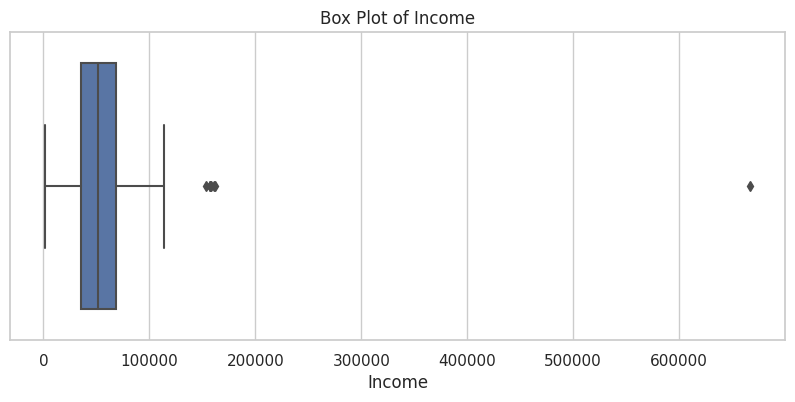

In [24]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Income'])
plt.title('Box Plot of Income')
plt.show()

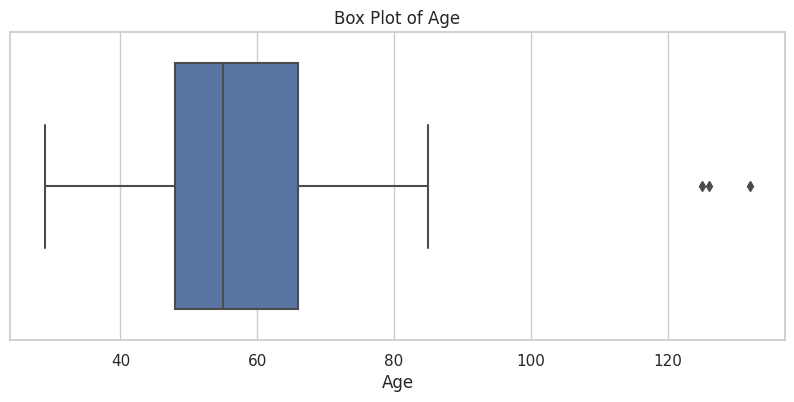

In [25]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Age'])
plt.title('Box Plot of Age')
plt.show()

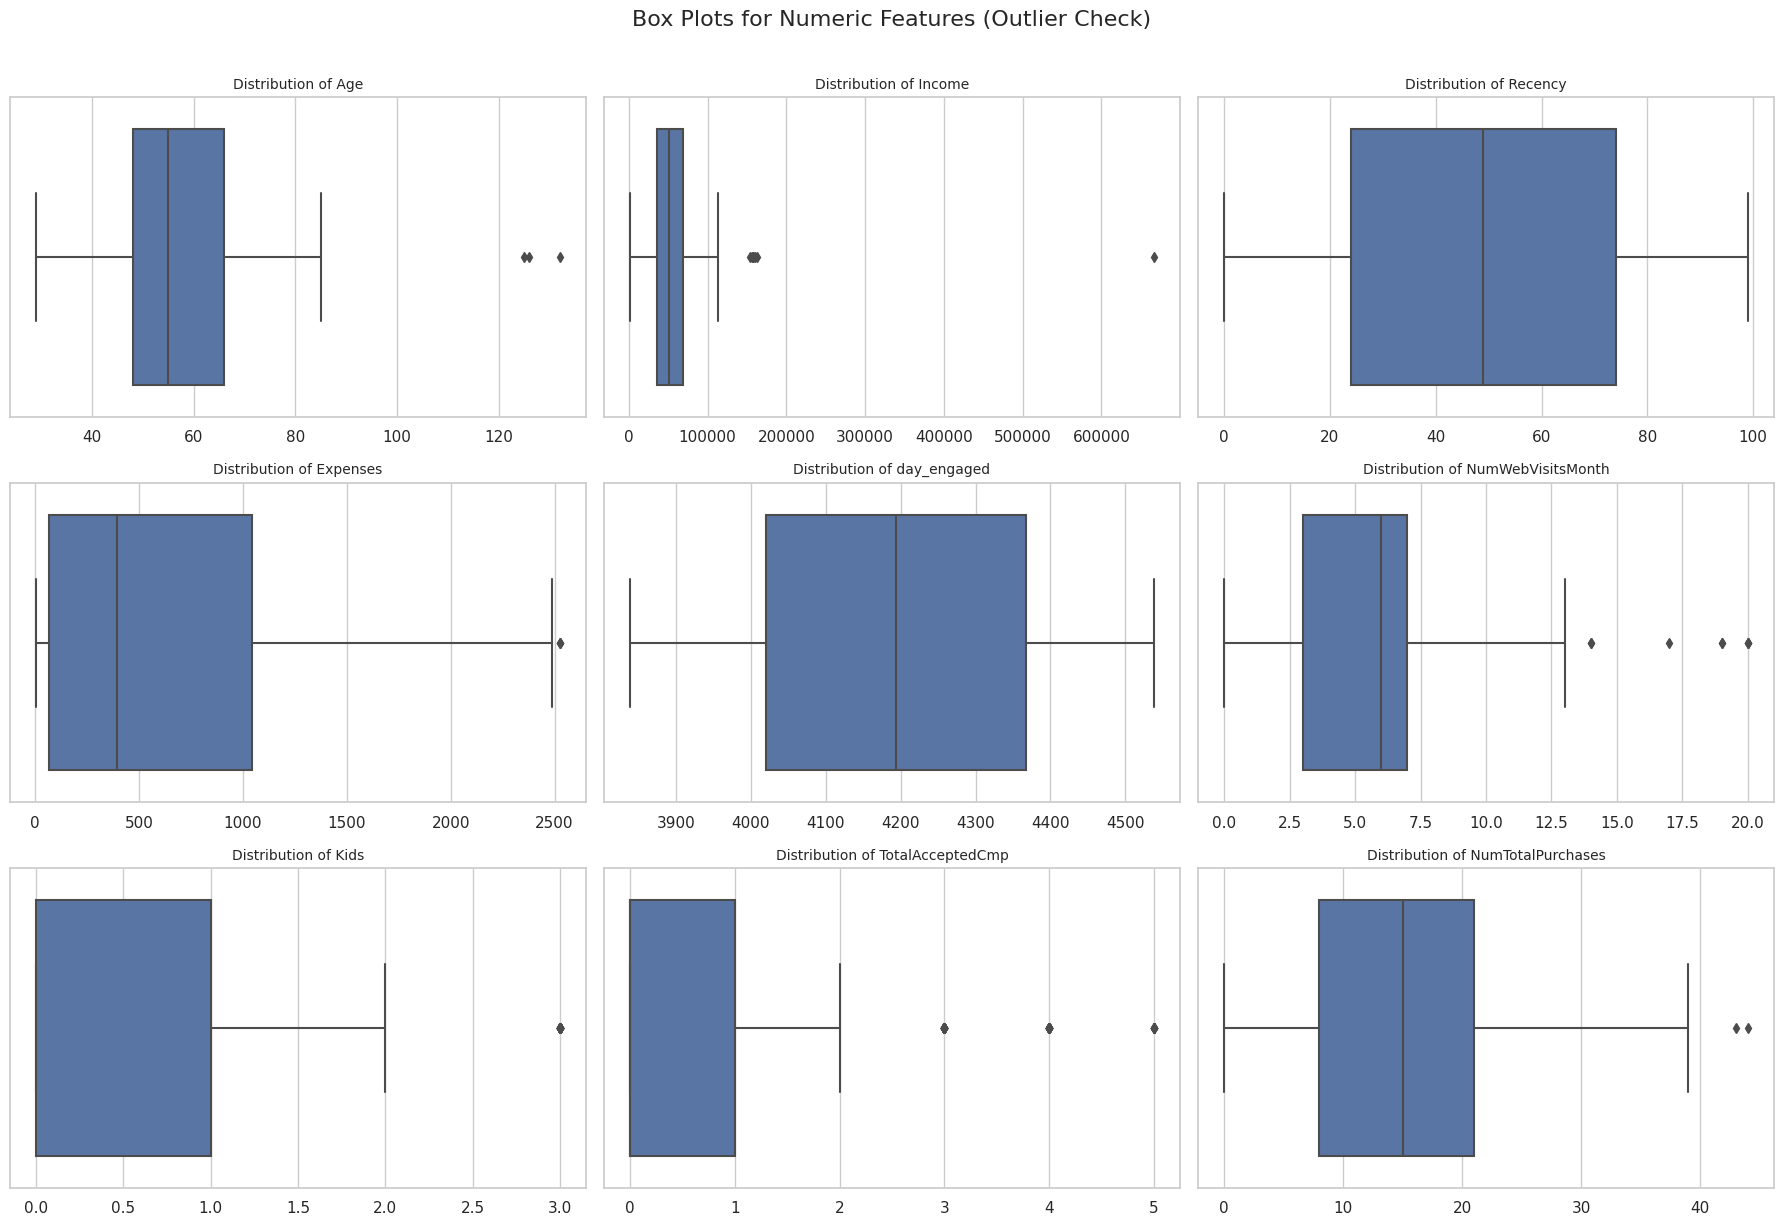

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# TASK: Create Box Plots for all continuous numeric columns to check for outliers

# 1. Define the list of continuous numeric columns to check
# We exclude ID, and the newly created binary/categorical columns (which are now encoded)
# The 'Mnt...' and 'Num...' columns were dropped and replaced by 'Expenses' and 'NumTotalPurchases'
numeric_features = [
    'Age', 'Income', 'Recency', 'Expenses', 'day_engaged',
    'NumWebVisitsMonth', 'Kids', 'TotalAcceptedCmp', 'NumTotalPurchases'
]

# 2. Setup the plot layout (e.g., 6 rows, 3 columns)
num_plots = len(numeric_features)
n_rows = (num_plots // 3) + (num_plots % 3 > 0) # Calculate required rows
n_cols = 3

plt.figure(figsize=(18, n_rows * 4)) # Adjust figure size dynamically
plt.suptitle('Box Plots for Numeric Features (Outlier Check)', fontsize=16, y=1.02)

# 3. Loop through the list and generate a box plot for each feature
for i, feature in enumerate(numeric_features):
    plt.subplot(n_rows, n_cols, i + 1)
    # Use sns.boxplot with the column data
    sns.boxplot(x=df[feature])
    plt.title(f'Distribution of {feature}', fontsize=10)
    plt.xlabel('') # Clear x-axis label for cleaner view

plt.tight_layout(rect=[0, 0, 1, 1.01]) # Adjust layout to prevent overlap
plt.show()

**Question:** Why can outliers be a problem in data analysis and machine learning?

**Your Answer Here:**

*Type your explanation here. Think about how a very large or small value might affect calculations like the mean.*

### 2. Handling Outliers

**Task:** Remove the rows that contain these outliers. A common method is to remove values that are outside of 1.5 times the Interquartile Range (IQR). We will remove outliers from `Income` and `Age`.

In [27]:
print(f"Original shape: {df.shape}")

# TASK: Remove outliers based on the IQR method
import numpy as np

# TASK: Remove outliers from 'Income' and 'Age' using the IQR method (1.5 * IQR)

# --- 1. Handle 'Income' Outliers ---
Q1_income = df['Income'].quantile(0.25)
Q3_income = df['Income'].quantile(0.75)
IQR_income = Q3_income - Q1_income
upper_bound_income = Q3_income + 1.5 * IQR_income
lower_bound_income = Q1_income - 1.5 * IQR_income # Usually 0 for income

# Filter the DataFrame: keep rows where Income is within the bounds
df = df[(df['Income'] <= upper_bound_income) & (df['Income'] >= lower_bound_income)].copy()
income_removed_count = df.shape[0] - df.shape[0]

# --- 2. Handle 'Age' Outliers ---
Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
upper_bound_age = Q3_age + 1.5 * IQR_age
lower_bound_age = Q1_age - 1.5 * IQR_age

# Filter the DataFrame again: keep rows where Age is within the bounds
df = df[(df['Age'] <= upper_bound_age) & (df['Age'] >= lower_bound_age)].copy()

print(" Outlier removal completed for 'Income' and 'Age' using 1.5 * IQR.")
print(f"Total number of rows remaining in DataFrame: {df.shape[0]}")

print(f"Shape after removing outliers: {df.shape}")

Original shape: (2240, 12)
 Outlier removal completed for 'Income' and 'Age' using 1.5 * IQR.
Total number of rows remaining in DataFrame: 2229
Shape after removing outliers: (2229, 12)


---

## 🔪 Part 6: Data Splitting & Feature Scaling

**Goal:** To prepare the final dataset for training and testing a model.

### 1. Train-Test Split

**Explain:** Why is it essential to split your data into a training set and a testing set?

**Your Answer Here:**

*Type your explanation here. What would happen if we tested the model on the same data it was trained on? Would that give us a true measure of its performance?*

**Task:** Define your target variable (`y`) as `NumTotalPurchases` and your features (`X`) as the rest of the columns. Use `train_test_split` to split your data into 85% for training and 15% for testing.

In [28]:
from sklearn.model_selection import train_test_split

# TASK: Define X and y
from sklearn.model_selection import train_test_split


target_variable = 'NumTotalPurchases'
y = df[target_variable]


X = df.drop(columns=[target_variable])



# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,  # 15% for testing
    random_state=42  # For reproducibility
)

print("Data successfully split into Training (85%) and Testing (15%).")
print("\n--- Split Dimensions ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")



Data successfully split into Training (85%) and Testing (15%).

--- Split Dimensions ---
X_train shape: (1894, 11)
X_test shape: (335, 11)
y_train shape: (1894,)
y_test shape: (335,)


### 2. Feature Scaling

**Explain:** What is the importance of feature scaling? What is the difference between `StandardScaler` and `MinMaxScaler`?

**Your Answer Here:**

*Type your explanation here. Think about how models might treat a feature with a range of 0-1 versus a feature with a range of 10,000-100,000.*

Handling Magnitude Differences ,It gives more weight to features with a wider range. That is, the model will mistakenly believe that Income is hundreds of times more important than Recency, simply because its numbers are larger.

also first sacale to traning set to Preventing Data Leakage

**Task:** Use `StandardScaler` to scale the numerical features in your data. **Important:** `fit` the scaler **only** on the training data and then `transform` both the training and testing data.

In [29]:
from sklearn.preprocessing import StandardScaler


# 1. Identify the continuous numerical columns to scale
# We select all columns from X_train as they are all numeric now, but we can be specific
scaling_cols = X_train.columns

# 2. Initialize the StandardScaler
scaler = StandardScaler()

# 3. Fit the scaler ONLY on the training data (X_train)
# This calculates the mean and std dev from the training set
scaler.fit(X_train[scaling_cols])

# 4. Transform both the training and testing data using the fitted scaler
# This scales the data and overwrites the original features in both sets

X_train[scaling_cols] = scaler.transform(X_train[scaling_cols])
X_test[scaling_cols] = scaler.transform(X_test[scaling_cols])

print(" Data Scaling completed successfully using StandardScaler.")
print("Scaler fitted only on X_train and applied to both X_train and X_test.")

# Verification: Display the head of the scaled training data (values should be centered around 0)
print("\nVerifying scaled values in X_train (first 5 rows):")
print(X_train.head())


 Data Scaling completed successfully using StandardScaler.
Scaler fitted only on X_train and applied to both X_train and X_test.

Verifying scaled values in X_train (first 5 rows):
      Education  Marital_Status    Income   Recency  NumWebVisitsMonth  \
1966  -0.161252       -0.733885  0.632724  0.332737          -0.147315   
955   -0.161252       -0.733885 -1.701343  0.020978           1.103875   
222   -0.161252       -0.733885  1.278156 -1.607098          -0.981442   
1228  -0.161252       -0.733885  0.154395  0.505937          -0.564379   
240   -0.161252        1.362612  1.073599  1.683693          -0.981442   

      Complain       Age     Kids  Expenses  TotalAcceptedCmp  day_engaged  
1966 -0.083134 -0.274835  0.06232  0.372393         -0.504797    -0.516327  
955  -0.083134 -0.615279  1.38855 -0.921792         -0.504797     0.747699  
222  -0.083134 -0.104614  1.38855  0.189190         -0.504797    -1.382234  
1228 -0.083134 -0.530168  0.06232 -0.330165         -0.504797    -

**Question:** What is the risk if you `fit` the scaler on the entire dataset *before* splitting it into training and testing sets?

**Your Answer Here:**

*Type your answer here. This is a concept called 'data leakage'. What information from the test set would 'leak' into the training process if you did this?*

---

## 🌟 Bonus Section: Dealing with Imbalanced Data (Theory)

**Goal:** To understand the challenges of working with imbalanced datasets.

**Theoretical Task:** Imagine you want to build a model to predict if a customer responded to *any* campaign.

In [30]:
# TASK 1: Create a new binary column 'Responded'

# TASK 2: Check the class distribution


**Task:** Briefly research and explain **two problems** that can arise from training a model on imbalanced data. Then, name and briefly describe **two techniques** used to solve this problem.

**Your Answer Here:**

**Problems:**
1. ...
2. ...

**Techniques:**
1. **SMOTE (Synthetic Minority Over-sampling Technique):** ...
2. **Undersampling:** ...

## 📊 Part 7: Building & Evaluating Multiple Regression Models

**Goal:** To train and compare four different regression models, evaluate their performance, and understand which model performs best on this dataset.**



### 1. Introduction to Regression Modeling
Regression models help us predict **numerical values**. Since our target variable is:

```
NumTotalPurchases
```
This is a continuous value, so we will use **Regression Models**.

In this part, you will experiment with **four different models**:

1. **Linear Regression** (Baseline Model)
2. **Random Forest Regressor** (Tree-based Ensemble Model)
3. **Gradient Boosting Regressor** (Boosted Trees Model)
4. **XGBoost Regressor** (Advanced Boosting — optional if not installed)

These models help you understand how different algorithms behave on the same dataset.

### 2. Train the Models

**Task:** Train all four models using the training dataset.

### 3. Make Predictions

**Task:** Use each model to predict values on the test set.

### 4. Evaluate the Model Performance

Regression models are evaluated using several key metrics. In this assignment, you will compute:

- **MAE (Mean Absolute Error)**: Measures the average absolute difference between predicted and actual values.
- **MSE (Mean Squared Error)**: Squares the errors, penalizing larger mistakes.
- **RMSE (Root Mean Squared Error)**: Square root of MSE (most commonly used).
- **R² Score**: Indicates how well the model explains the variation in the target.

**Task:** Evaluate all models and display results in a clean table.

### 5. Visualize Errors: Residual Plot (Optional but Recommended)

A **residual plot** shows how far predictions deviate from actual values. Ideally, residuals should be randomly scattered around zero.

**Task:**  Choose one model (the best performer) and visualize its residuals.

**Question:** What does the residual plot tell you? Are errors evenly distributed? Do you notice patterns?

**Your Answer Here:**
-
-
-
### 🎉 Final Thoughts in This part
You have now:
- Trained **4 different regression models**
- Compared their performance side-by-side
- Visualized residuals for the best model
- Learned that models behave differently depending on the dataset

This prepares you for real-world model experimentation and model selection.



In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# Dictionary to store trained models
models = {}

# List of models to train
model_list = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42),
    "XGBoost Regressor": xgb.XGBRegressor(random_state=42, objective='reg:squarederror')
}

print("--- Starting Model Training ---")
for name, model in model_list.items():
    start_time = time.time()
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    end_time = time.time()
    models[name] = model
    print(f" {name} trained in {end_time - start_time:.2f} seconds.")

print("\nAll models are trained and ready for prediction.")

--- Starting Model Training ---
Training Linear Regression...
 Linear Regression trained in 0.02 seconds.
Training Random Forest Regressor...
 Random Forest Regressor trained in 1.02 seconds.
Training Gradient Boosting Regressor...
 Gradient Boosting Regressor trained in 0.39 seconds.
Training XGBoost Regressor...
 XGBoost Regressor trained in 0.17 seconds.

All models are trained and ready for prediction.


In [32]:
# Dictionary to store evaluation results
results = {'Model': [], 'MAE': [], 'MSE': [], 'RMSE': [], 'R2 Score': []}

print("\n--- Starting Model Evaluation ---")
for name, model in models.items():

    # Task 3: Make Predictions on the test set
    y_pred = model.predict(X_test)

    # Task 4: Evaluate the Model Performance

    # Calculate Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Store Results
    results['Model'].append(name)
    results['MAE'].append(mae)
    results['MSE'].append(mse)
    results['RMSE'].append(rmse)
    results['R2 Score'].append(r2)

    print(f"Evaluated {name}. R2 Score: {r2:.4f}")

# Convert results dictionary to a clean DataFrame for display
results_df = pd.DataFrame(results)

print("\n--- Model Performance Summary ---")
print(results_df.sort_values(by='R2 Score', ascending=False))


--- Starting Model Evaluation ---
Evaluated Linear Regression. R2 Score: 0.6166
Evaluated Random Forest Regressor. R2 Score: 0.8572
Evaluated Gradient Boosting Regressor. R2 Score: 0.8331
Evaluated XGBoost Regressor. R2 Score: 0.8489

--- Model Performance Summary ---
                         Model       MAE        MSE      RMSE  R2 Score
1      Random Forest Regressor  1.802090   7.925170  2.815168  0.857168
3            XGBoost Regressor  1.796151   8.381250  2.895039  0.848949
2  Gradient Boosting Regressor  2.031760   9.260460  3.043100  0.833103
0            Linear Regression  3.535207  21.275072  4.612491  0.616569


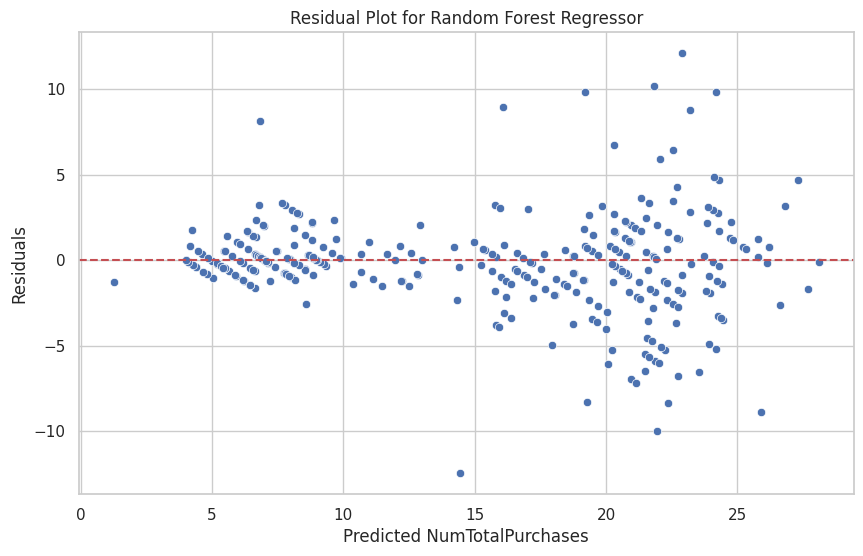

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the best performing model (Random Forest Regressor)
best_model_name = results_df.sort_values(by='R2 Score', ascending=False).iloc[0]['Model']
best_model = models[best_model_name]

# Make predictions with the best model
y_pred_best = best_model.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred_best

# Create a residual plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_best, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted NumTotalPurchases')
plt.ylabel('Residuals')
plt.title(f'Residual Plot for {best_model_name}')
plt.grid(True)
plt.show()

**Question:** What does the residual plot tell you? Are errors evenly distributed? Do you notice patterns?

**Your Answer Here:**
-
-
-

**Logarithmic transformation on the target variable for optimization**

In [34]:
def evaluate_models(models_dict, X_test_data, y_test_data, is_log_transformed=False):
    results = {'Model': [], 'RMSE': [], 'R2 Score': []}
    for name, model in models_dict.items():
        y_pred_log = model.predict(X_test_data)

        if is_log_transformed:
            # Inverse transform predictions and actuals to original scale for evaluation
            y_pred = np.expm1(y_pred_log) # exp(x) - 1
            y_actual = np.expm1(y_test_data)
        else:
            y_pred = y_pred_log
            y_actual = y_test_data

        rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
        r2 = r2_score(y_actual, y_pred)

        results['Model'].append(name)
        results['RMSE'].append(rmse)
        results['R2 Score'].append(r2)
    return pd.DataFrame(results).set_index('Model')



In [35]:

# 1. Evaluate models on RAW data (Current state)
# We assume 'models' dictionary contains your currently trained models
print("--- Evaluating Models on RAW Data ---")
df_results_raw = evaluate_models(models, X_test, y_test, is_log_transformed=False)
df_results_raw.columns = ['RMSE (Raw)', 'R2 (Raw)'] # Rename for comparison


--- Evaluating Models on RAW Data ---


In [36]:
# ---------------------------------------------------------

# 2. Apply Log Transformation to Target Variable
print("\n--- Applying Log Transformation & Retraining ---")
y_train_log = np.log1p(y_train) # log(y + 1)
y_test_log = np.log1p(y_test)

# Dictionary to store new log-trained models
models_log = {}

# Retrain models on log-transformed target
for name, model in model_list.items():
    # Re-initialize model to avoid issues from previous training
    if name == "Linear Regression":
        new_model = type(model_list[name])() # Linear Regression does not take random_state
    elif 'XGBoost' in name:
        new_model = type(model_list[name])(random_state=42, objective='reg:squarederror')
    else:
        new_model = type(model_list[name])(random_state=42)
    new_model.fit(X_train, y_train_log)
    models_log[name] = new_model



--- Applying Log Transformation & Retraining ---


In [37]:
# 3. Evaluate models on LOG data
# Note: The function handles converting predictions back to original scale for fair comparison
df_results_log = evaluate_models(models_log, X_test, y_test_log, is_log_transformed=True)
df_results_log.columns = ['RMSE (Log)', 'R2 (Log)']

# ---------------------------------------------------------


In [38]:

# 4. Combine and Compare Results
comparison_df = pd.concat([df_results_raw, df_results_log], axis=1)

# Calculate improvement in R2
comparison_df['R2 Improvement'] = comparison_df['R2 (Log)'] - comparison_df['R2 (Raw)']

print("\n Final Comparison Table (Higher R2 & Lower RMSE is better):")
print(comparison_df.sort_values(by='R2 (Log)', ascending=False))


 Final Comparison Table (Higher R2 & Lower RMSE is better):
                             RMSE (Raw)  R2 (Raw)  RMSE (Log)  R2 (Log)  \
Model                                                                     
Random Forest Regressor        2.815168  0.857168    2.846636  0.853957   
XGBoost Regressor              2.895039  0.848949    2.903907  0.848022   
Gradient Boosting Regressor    3.043100  0.833103    3.042802  0.833136   
Linear Regression              4.612491  0.616569    5.739549  0.406294   

                             R2 Improvement  
Model                                        
Random Forest Regressor           -0.003211  
XGBoost Regressor                 -0.000927  
Gradient Boosting Regressor        0.000033  
Linear Regression                 -0.210275  




### **Congratulations on completing the assignment!**